# W05

## Parte 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [33]:
mu = 1 
sigma = 0.2  
N = 30

data = np.random.normal(mu, sigma, N)
data

array([0.80506367, 1.15741692, 1.23171912, 0.83586354, 1.19267523,
       1.08255619, 1.16441203, 1.3793586 , 0.95092238, 0.84925277,
       0.82209711, 0.83683794, 0.98457966, 1.06823039, 1.05533816,
       1.16543665, 1.00260038, 1.29070682, 0.94706863, 1.54403383,
       1.12513347, 0.82856849, 0.7858215 , 1.09649448, 0.95530744,
       1.1428001 , 1.09464752, 0.98543422, 0.83064126, 0.69703056])

In [34]:
x = np.linspace(0, 2, 1000)
likelihoods = []

for x_i in data:
    likelihood = norm.pdf(x, loc=x_i, scale=sigma)  # Verosimiglianza per x_i
    likelihoods.append(likelihood)

likelihood_p = np.prod(likelihoods, axis=0)

Text(0, 0.5, 'Likelihood')

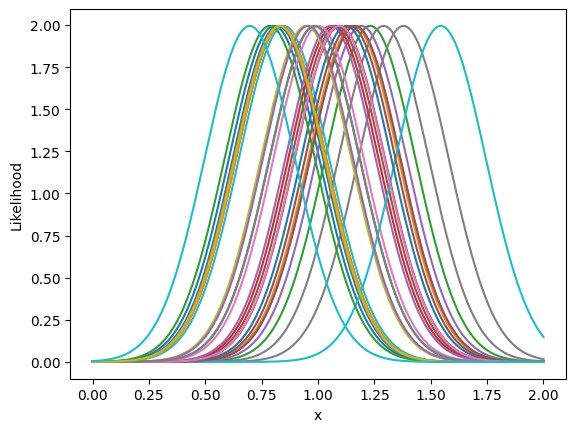

In [37]:
for i in range(N):
    plt.plot(x, likelihoods[i])

plt.xlabel('x')
plt.ylabel('Likelihood')

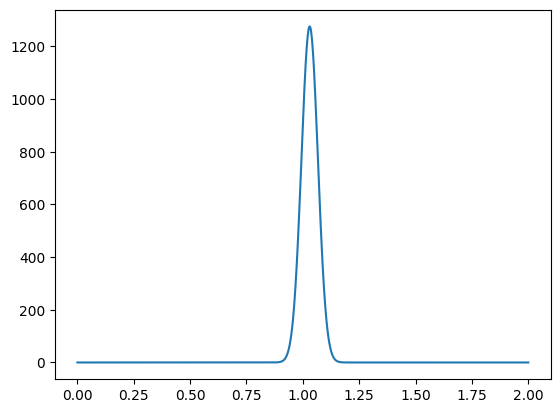

In [52]:
plt.plot(x, likelihood_p)

In [48]:
max_likelihood_i = np.argmax(likelihood_p)
mle_mu = x[max_likelihood_i]

print(f"mu vero: {mu}")
print(f"MLE: {mle_mu:.3f}")

mu vero: 1
MLE: 1.031


## Parte 2

In [53]:
def log_ll(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma) ** 2 - np.log(sigma * np.sqrt(2 * np.pi))

In [55]:
mu_v = np.linspace(0.8, 1.2, 500)
log_ll_v = np.array([np.sum(log_ll(data, mu_val, sigma)) for mu_val in mu_v])
log_ll_v

array([-1.27325478e+01, -1.25943509e+01, -1.24566359e+01, -1.23194029e+01,
       -1.21826518e+01, -1.20463826e+01, -1.19105953e+01, -1.17752900e+01,
       -1.16404666e+01, -1.15061251e+01, -1.13722655e+01, -1.12388879e+01,
       -1.11059922e+01, -1.09735784e+01, -1.08416465e+01, -1.07101966e+01,
       -1.05792286e+01, -1.04487425e+01, -1.03187384e+01, -1.01892161e+01,
       -1.00601758e+01, -9.93161745e+00, -9.80354100e+00, -9.67594647e+00,
       -9.54883387e+00, -9.42220320e+00, -9.29605445e+00, -9.17038762e+00,
       -9.04520272e+00, -8.92049975e+00, -8.79627871e+00, -8.67253959e+00,
       -8.54928239e+00, -8.42650712e+00, -8.30421378e+00, -8.18240236e+00,
       -8.06107287e+00, -7.94022531e+00, -7.81985967e+00, -7.69997595e+00,
       -7.58057416e+00, -7.46165430e+00, -7.34321636e+00, -7.22526035e+00,
       -7.10778627e+00, -6.99079411e+00, -6.87428387e+00, -6.75825557e+00,
       -6.64270918e+00, -6.52764473e+00, -6.41306220e+00, -6.29896159e+00,
       -6.18534291e+00, -

In [56]:
dlog_ll = np.diff(log_ll_v)  #prima derivata 
d2log_ll = np.diff(dlog_ll)  #seconda derivata 

In [59]:
delta_mu = mu_v[1] - mu_v[0]  # passo di mu

fisher_matrix_error = -d2log_ll/(delta_mu**2)
mu_error_fisher = np.sqrt(1/fisher_matrix_error)

fisher_matrix = -np.mean(d2log_ll)/(delta_mu**2)
mu_error_fisher_a = np.sqrt(1/fisher_matrix)

print(f"Errore dalla Fisher Matrix (numerico): {mu_error_fisher[0]}")
print(f"Errore dalla Fisher Matrix (analitico): {mu_error_fisher_a}")

Errore dalla Fisher Matrix (numerico): 0.036514837166280345
Errore dalla Fisher Matrix (analitico): 0.03651483716701185


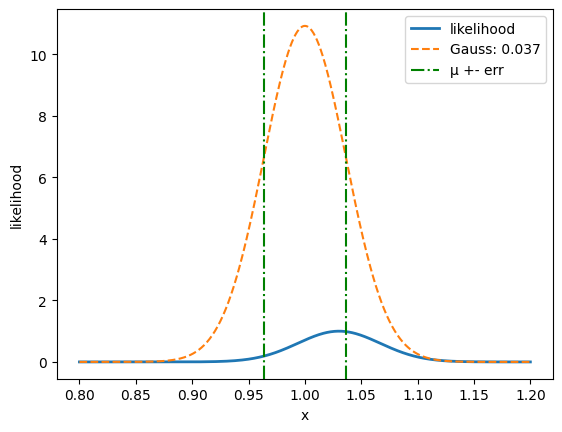

In [67]:
x = np.linspace(0.8, 1.2, 500)
ll_gauss = norm.pdf(x, mu, mu_error_fisher_a)  

plt.plot(mu_v, np.exp(log_ll_v - np.max(log_ll_v)), label='likelihood', linewidth=2)
plt.plot(x, ll_gauss, label=f'Gauss: {mu_error_fisher_a:.3f}', linestyle='--')

plt.axvline(mu + mu_error_fisher_a, color='green', linestyle='-.', label=f'µ +- err')
plt.axvline(mu - mu_error_fisher_a, color='green', linestyle='-.')

plt.xlabel('x')
plt.ylabel('likelihood')
plt.legend()